# Model 2: GARCH(1,1) Time-Varying Volatility

**Modification:** Replace 52-week rolling vol with GARCH(1,1) conditional volatility.

**GARCH(1,1) specification:**
```
σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}
```

**Why GARCH:**
- Data-driven (no arbitrary window choice)
- Captures volatility clustering
- Recent shocks matter more (exponential decay)
- Standard in academic finance

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm, linregress
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# GARCH
from arch import arch_model

In [20]:
# =============================================================================
# CONFIGURATION
# =============================================================================
PANEL_PATH = "data/processed/merton_panel.csv"

# Model parameters
T = 5.0  # Time horizon
TARGET_RATIO = 1  # Asset scaling

---
## 1. Load Panel

In [21]:
panel = pd.read_csv(PANEL_PATH, parse_dates=['date'])
panel = panel.sort_values(['country', 'date']).reset_index(drop=True)

print(f"Panel: {len(panel)} obs, {panel['country'].nunique()} countries")
print(f"Date range: {panel['date'].min().date()} to {panel['date'].max().date()}")

Panel: 10961 obs, 20 countries
Date range: 2014-01-03 to 2024-12-27


---
## 2. Fit GARCH(1,1) per Country

In [22]:
def fit_garch(returns, annualize=True):
    """
    Fit GARCH(1,1) to return series.
    
    Returns:
        sigma: Conditional volatility series (annualized if annualize=True)
        params: Dict with omega, alpha, beta
    """
    # Drop NaN and check length
    returns = returns.dropna()
    if len(returns) < 100:
        return None, None
    
    # Scale to percentage for numerical stability
    returns_pct = returns * 100
    
    try:
        # Fit GARCH(1,1) with zero mean (returns already demeaned roughly)
        model = arch_model(
            returns_pct, 
            vol='Garch', 
            p=1, q=1,
            mean='Zero',
            rescale=False
        )
        result = model.fit(disp='off', show_warning=False)
        
        # Extract conditional volatility
        sigma = result.conditional_volatility / 100  # Back to decimal
        
        if annualize:
            sigma = sigma * np.sqrt(52)  # Weekly to annual
        
        # Extract parameters
        params = {
            'omega': result.params.get('omega', np.nan),
            'alpha': result.params.get('alpha[1]', np.nan),
            'beta': result.params.get('beta[1]', np.nan),
        }
        params['persistence'] = params['alpha'] + params['beta']
        
        return sigma, params
    
    except Exception as e:
        print(f"GARCH fitting error: {e}")
        return None, None

In [23]:
# Fit GARCH for each country
garch_params = []
panel['sigma_garch'] = np.nan

for country in panel['country'].unique():
    mask = panel['country'] == country
    returns = panel.loc[mask, 'msci_ret_weekly'].copy()
    
    sigma, params = fit_garch(returns)
    
    if sigma is not None:
        # Align sigma with panel index
        panel.loc[mask, 'sigma_garch'] = sigma.values
        
        garch_params.append({
            'country': country,
            'group': panel.loc[mask, 'group'].iloc[0],
            **params,
            'n_obs': len(returns.dropna())
        })
        print(f"{country}: α={params['alpha']:.3f}, β={params['beta']:.3f}, persistence={params['persistence']:.3f}")
    else:
        print(f"{country}: GARCH failed (insufficient data)")

garch_df = pd.DataFrame(garch_params)
print(f"\nSuccessfully fitted GARCH for {len(garch_df)} countries")

Brazil: α=0.133, β=0.767, persistence=0.901
Chile: α=0.133, β=0.828, persistence=0.961
China: α=0.173, β=0.598, persistence=0.771
Colombia: α=0.246, β=0.705, persistence=0.951
Czechia: α=0.126, β=0.843, persistence=0.969
Egypt: α=0.027, β=0.705, persistence=0.733
Greece: α=0.069, β=0.909, persistence=0.978
Hungary: α=0.230, β=0.603, persistence=0.833
India: α=0.143, β=0.704, persistence=0.847
Indonesia: α=0.162, β=0.730, persistence=0.893
Malaysia: α=0.143, β=0.792, persistence=0.935
Mexico: α=0.169, β=0.696, persistence=0.865
Peru: α=0.102, β=0.849, persistence=0.950
Philippines: α=0.113, β=0.851, persistence=0.964
Poland: α=0.167, β=0.699, persistence=0.866
Saudi Arabia: α=0.071, β=0.722, persistence=0.794
South Africa: α=0.135, β=0.725, persistence=0.860
South Korea: α=0.116, β=0.800, persistence=0.916
Thailand: α=0.118, β=0.792, persistence=0.910
Turkey: α=0.160, β=0.519, persistence=0.679

Successfully fitted GARCH for 20 countries


In [24]:
# GARCH parameter summary
print("\nGARCH(1,1) Parameter Summary:")
print(garch_df[['alpha', 'beta', 'persistence']].describe().round(3))


GARCH(1,1) Parameter Summary:
        alpha    beta  persistence
count  20.000  20.000       20.000
mean    0.137   0.742        0.879
std     0.051   0.096        0.083
min     0.027   0.519        0.679
25%     0.115   0.703        0.843
50%     0.134   0.728        0.897
75%     0.163   0.807        0.950
max     0.246   0.909        0.978


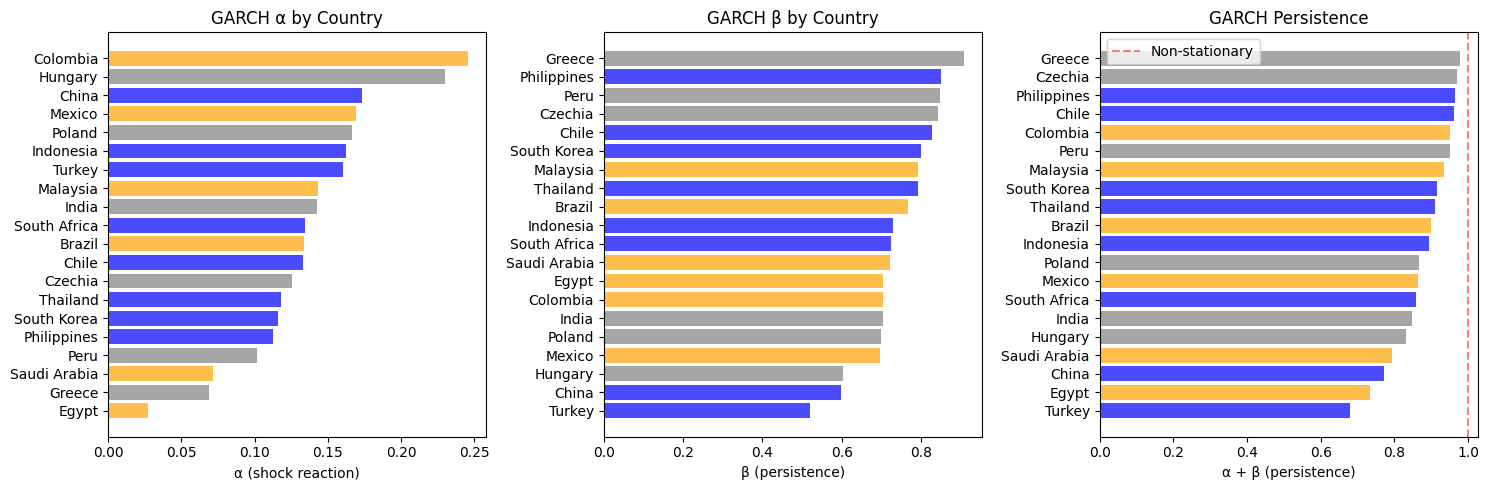

In [25]:
# Visualize GARCH parameters
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Alpha (shock reaction)
ax = axes[0]
garch_sorted = garch_df.sort_values('alpha', ascending=True)
colors = ['orange' if g == 'oil_exporter' else ('blue' if g == 'control' else 'gray') 
          for g in garch_sorted['group']]
ax.barh(garch_sorted['country'], garch_sorted['alpha'], color=colors, alpha=0.7)
ax.set_xlabel('α (shock reaction)')
ax.set_title('GARCH α by Country')

# Beta (persistence)
ax = axes[1]
garch_sorted = garch_df.sort_values('beta', ascending=True)
colors = ['orange' if g == 'oil_exporter' else ('blue' if g == 'control' else 'gray') 
          for g in garch_sorted['group']]
ax.barh(garch_sorted['country'], garch_sorted['beta'], color=colors, alpha=0.7)
ax.set_xlabel('β (persistence)')
ax.set_title('GARCH β by Country')

# Persistence (alpha + beta)
ax = axes[2]
garch_sorted = garch_df.sort_values('persistence', ascending=True)
colors = ['orange' if g == 'oil_exporter' else ('blue' if g == 'control' else 'gray') 
          for g in garch_sorted['group']]
ax.barh(garch_sorted['country'], garch_sorted['persistence'], color=colors, alpha=0.7)
ax.axvline(1.0, color='r', linestyle='--', alpha=0.5, label='Non-stationary')
ax.set_xlabel('α + β (persistence)')
ax.set_title('GARCH Persistence')
ax.legend()

plt.tight_layout()
plt.show()

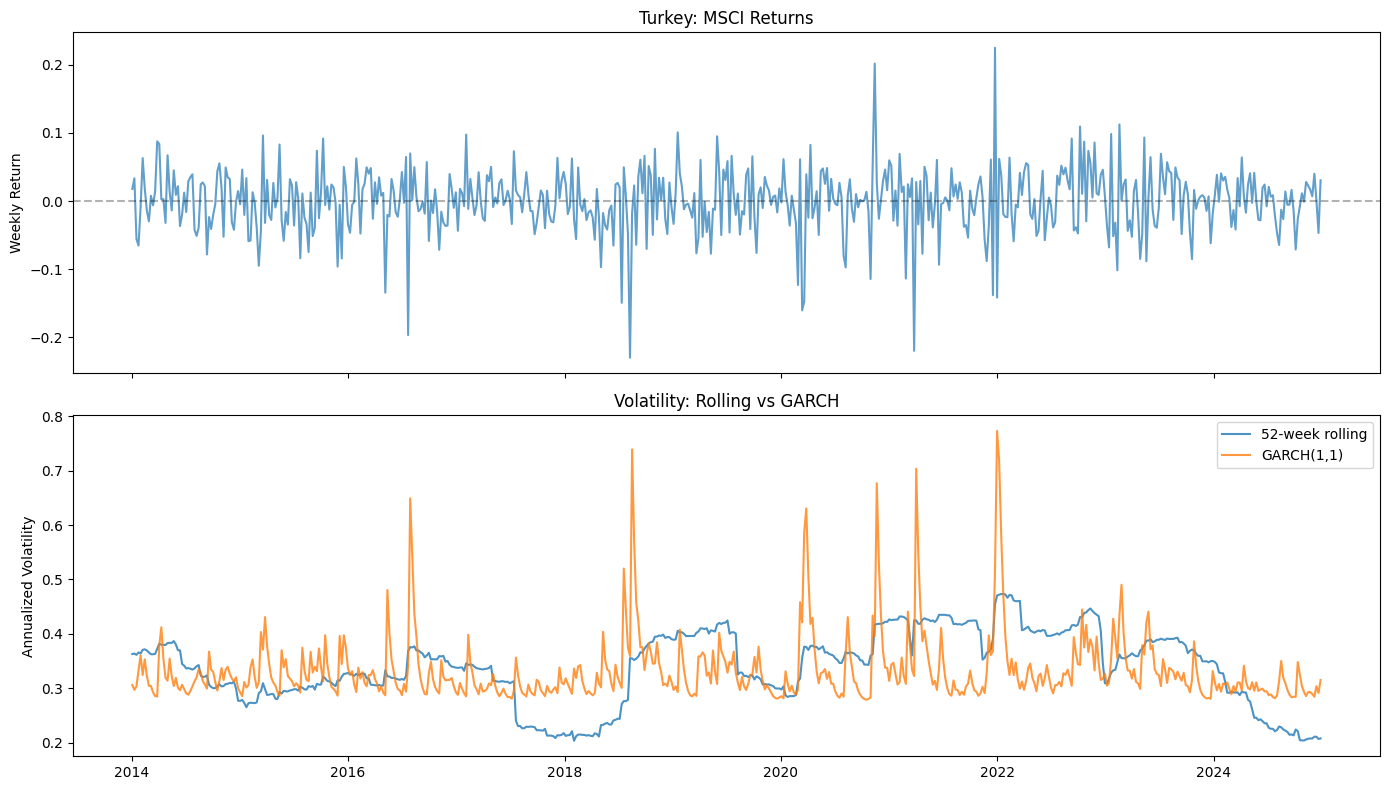

In [26]:
# Compare GARCH vol vs rolling vol for one country
sample_country = 'Turkey'
sample = panel[panel['country'] == sample_country].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Returns
ax = axes[0]
ax.plot(sample['date'], sample['msci_ret_weekly'], alpha=0.7)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_ylabel('Weekly Return')
ax.set_title(f'{sample_country}: MSCI Returns')

# Volatility comparison
ax = axes[1]
ax.plot(sample['date'], sample['msci_vol_52w'], label='52-week rolling', alpha=0.8)
ax.plot(sample['date'], sample['sigma_garch'], label='GARCH(1,1)', alpha=0.8)
ax.set_ylabel('Annualized Volatility')
ax.set_title('Volatility: Rolling vs GARCH')
ax.legend()

plt.tight_layout()
plt.show()

---
## 3. Scale Assets

In [27]:
# Same scaling as baseline
scale_factors = panel.groupby('country').apply(
    lambda g: TARGET_RATIO * g['default_barrier'].mean() / g['msci_index'].mean()
).reset_index()
scale_factors.columns = ['country', 'scale_factor']

panel = panel.merge(scale_factors, on='country', how='left')
panel['A'] = panel['msci_index'] * panel['scale_factor']

---
## 4. Compute d₂ and PD

In [28]:
def compute_d2(A, B, sigma, r, T=1.0):
    """Merton distance-to-default."""
    with np.errstate(divide='ignore', invalid='ignore'):
        d2 = (np.log(A / B) + (r - sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return d2

def compute_pd(d2):
    """Risk-neutral default probability."""
    return norm.cdf(-d2)

In [29]:
# Baseline (52-week rolling)
panel['d2_baseline'] = compute_d2(
    panel['A'], panel['default_barrier'], 
    panel['msci_vol_52w'], panel['rf'], T
)
panel['pd_baseline'] = compute_pd(panel['d2_baseline'])

# GARCH
panel['d2_garch'] = compute_d2(
    panel['A'], panel['default_barrier'], 
    panel['sigma_garch'], panel['rf'], T
)
panel['pd_garch'] = compute_pd(panel['d2_garch'])

print("PD Comparison:")
print(f"  Baseline: mean={panel['pd_baseline'].mean():.3f}, std={panel['pd_baseline'].std():.3f}")
print(f"  GARCH:    mean={panel['pd_garch'].mean():.3f}, std={panel['pd_garch'].std():.3f}")

PD Comparison:
  Baseline: mean=0.495, std=0.270
  GARCH:    mean=0.502, std=0.261


In [30]:
# Clean data
panel = panel.replace([np.inf, -np.inf], np.nan)
panel = panel.dropna(subset=['d2_baseline', 'd2_garch', 'pd_baseline', 'pd_garch'])
print(f"After cleaning: {len(panel)} obs, {panel['country'].nunique()} countries")

After cleaning: 10961 obs, 20 countries


---
## 5. Compute Changes for Regression

In [31]:
panel = panel.sort_values(['country', 'date'])

# Δln(CDS)
panel['ln_cds'] = np.log(panel['cds_spread'])
panel['d_ln_cds'] = panel.groupby('country')['ln_cds'].diff()

# ΔPD
panel['d_pd_baseline'] = panel.groupby('country')['pd_baseline'].diff()
panel['d_pd_garch'] = panel.groupby('country')['pd_garch'].diff()

# Time FE
panel['ym'] = panel['date'].dt.to_period('M').astype(str)

# Clean
reg_data = panel.dropna(subset=['d_ln_cds', 'd_pd_baseline', 'd_pd_garch'])
reg_data = reg_data.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['d_ln_cds', 'd_pd_baseline', 'd_pd_garch']
)

print(f"Regression sample: {len(reg_data)} obs, {reg_data['country'].nunique()} countries")

Regression sample: 10941 obs, 20 countries


---
## 6. Main Regression: Full Sample

In [32]:
# Baseline
m1 = smf.ols('d_ln_cds ~ d_pd_baseline + C(country) + C(ym)', data=reg_data).fit()

# GARCH
m2 = smf.ols('d_ln_cds ~ d_pd_garch + C(country) + C(ym)', data=reg_data).fit()

print("="*70)
print("FULL SAMPLE: BASELINE vs GARCH")
print("="*70)
print(f"{'Metric':<20} {'Baseline (52w)':>20} {'GARCH(1,1)':>20}")
print("-"*70)
print(f"{'β (ΔPD)':<20} {m1.params['d_pd_baseline']:>20.4f} {m2.params['d_pd_garch']:>20.4f}")
print(f"{'t-stat':<20} {m1.tvalues['d_pd_baseline']:>20.2f} {m2.tvalues['d_pd_garch']:>20.2f}")
print(f"{'R²':<20} {m1.rsquared:>20.4f} {m2.rsquared:>20.4f}")
print(f"{'N':<20} {int(m1.nobs):>20} {int(m2.nobs):>20}")
print("-"*70)
print(f"{'R² Improvement':<20} {'':<20} {m2.rsquared - m1.rsquared:>20.4f}")
print(f"{'% Change':<20} {'':<20} {(m2.rsquared/m1.rsquared - 1)*100:>19.1f}%")

FULL SAMPLE: BASELINE vs GARCH
Metric                     Baseline (52w)           GARCH(1,1)
----------------------------------------------------------------------
β (ΔPD)                            0.6459               0.4055
t-stat                              26.37                19.36
R²                                 0.1405               0.1158
N                                   10941                10941
----------------------------------------------------------------------
R² Improvement                                         -0.0247
% Change                                                -17.6%


---
## 7. Regression by Group

In [33]:
# Split
oil_sample = reg_data[reg_data['group'] == 'oil_exporter']
ctrl_sample = reg_data[reg_data['group'] == 'control']

print(f"Oil exporters: {oil_sample['country'].nunique()} countries, {len(oil_sample)} obs")
print(f"Controls: {ctrl_sample['country'].nunique()} countries, {len(ctrl_sample)} obs")

Oil exporters: 6 countries, 3126 obs
Controls: 8 countries, 4441 obs


In [34]:
# Run regressions by group
group_results = []

for group_name, sample in [('Oil Exporters', oil_sample), ('Controls', ctrl_sample)]:
    m1 = smf.ols('d_ln_cds ~ d_pd_baseline + C(country) + C(ym)', data=sample).fit()
    m2 = smf.ols('d_ln_cds ~ d_pd_garch + C(country) + C(ym)', data=sample).fit()
    
    group_results.append({
        'group': group_name,
        'n_countries': sample['country'].nunique(),
        'n_obs': len(sample),
        'beta_baseline': m1.params['d_pd_baseline'],
        't_baseline': m1.tvalues['d_pd_baseline'],
        'r2_baseline': m1.rsquared,
        'beta_garch': m2.params['d_pd_garch'],
        't_garch': m2.tvalues['d_pd_garch'],
        'r2_garch': m2.rsquared,
        'r2_improvement': m2.rsquared - m1.rsquared,
        'r2_pct_change': (m2.rsquared / m1.rsquared - 1) * 100
    })

group_df = pd.DataFrame(group_results)

print("\n" + "="*90)
print("BY GROUP: BASELINE vs GARCH")
print("="*90)
print(group_df.to_string(index=False))


BY GROUP: BASELINE vs GARCH
        group  n_countries  n_obs  beta_baseline  t_baseline  r2_baseline  beta_garch   t_garch  r2_garch  r2_improvement  r2_pct_change
Oil Exporters            6   3126       0.580765   14.918708     0.203092    0.375444 10.555006  0.174511       -0.028581     -14.072875
     Controls            8   4441       0.825887   23.613019     0.242094    0.490901 16.559836  0.195157       -0.046938     -19.388115


In [35]:
# Difference-in-differences
oil_imp = group_df[group_df['group'] == 'Oil Exporters']['r2_improvement'].values[0]
ctrl_imp = group_df[group_df['group'] == 'Controls']['r2_improvement'].values[0]

print("\n" + "="*50)
print("DIFFERENCE-IN-DIFFERENCES")
print("="*50)
print(f"Oil exporters R² improvement:  {oil_imp:+.4f}")
print(f"Controls R² improvement:       {ctrl_imp:+.4f}")
print(f"Diff-in-diff:                  {oil_imp - ctrl_imp:+.4f}")


DIFFERENCE-IN-DIFFERENCES
Oil exporters R² improvement:  -0.0286
Controls R² improvement:       -0.0469
Diff-in-diff:                  +0.0184


---
## 8. Country-Level Results

In [36]:
country_results = []

for country in reg_data['country'].unique():
    df = reg_data[reg_data['country'] == country]
    if len(df) < 50:
        continue
    
    # Baseline
    s1, _, r1, _, _ = linregress(df['d_pd_baseline'], df['d_ln_cds'])
    # GARCH
    s2, _, r2, _, _ = linregress(df['d_pd_garch'], df['d_ln_cds'])
    
    country_results.append({
        'country': country,
        'group': df['group'].iloc[0],
        'beta_baseline': s1,
        'r2_baseline': r1**2,
        'beta_garch': s2,
        'r2_garch': r2**2,
        'r2_improvement': r2**2 - r1**2
    })

country_df = pd.DataFrame(country_results).sort_values('r2_improvement', ascending=False)

print("Country-level R² comparison:")
print(country_df.to_string(index=False))

Country-level R² comparison:
     country        group  beta_baseline  r2_baseline  beta_garch  r2_garch  r2_improvement
      Greece        other       0.953231     0.013012    1.019018  0.015963        0.002951
      Poland        other       0.394971     0.058552    0.334772  0.061255        0.002703
Saudi Arabia oil_exporter       0.266047     0.034495    0.284372  0.036296        0.001802
       India        other      -0.023570     0.000528   -0.023056  0.000603        0.000076
       Egypt oil_exporter       0.096895     0.002929    0.109392  0.001941       -0.000988
    Thailand      control       0.431136     0.057090    0.401742  0.053093       -0.003997
       China      control       0.276888     0.016226    0.164932  0.009626       -0.006601
     Czechia        other       0.107064     0.015813    0.018221  0.000661       -0.015153
     Hungary        other       0.446236     0.080079    0.208252  0.040954       -0.039125
       Chile      control       1.338652     0.1153

In [37]:
# Summary by group
print("\nMean R² improvement by group:")
print(country_df.groupby('group')['r2_improvement'].agg(['mean', 'median', 'std']).round(4))


Mean R² improvement by group:
                mean  median     std
group                               
control      -0.0719 -0.0556  0.0619
oil_exporter -0.0759 -0.0703  0.0781
other        -0.0236 -0.0075  0.0377


---
## 9. Visualization

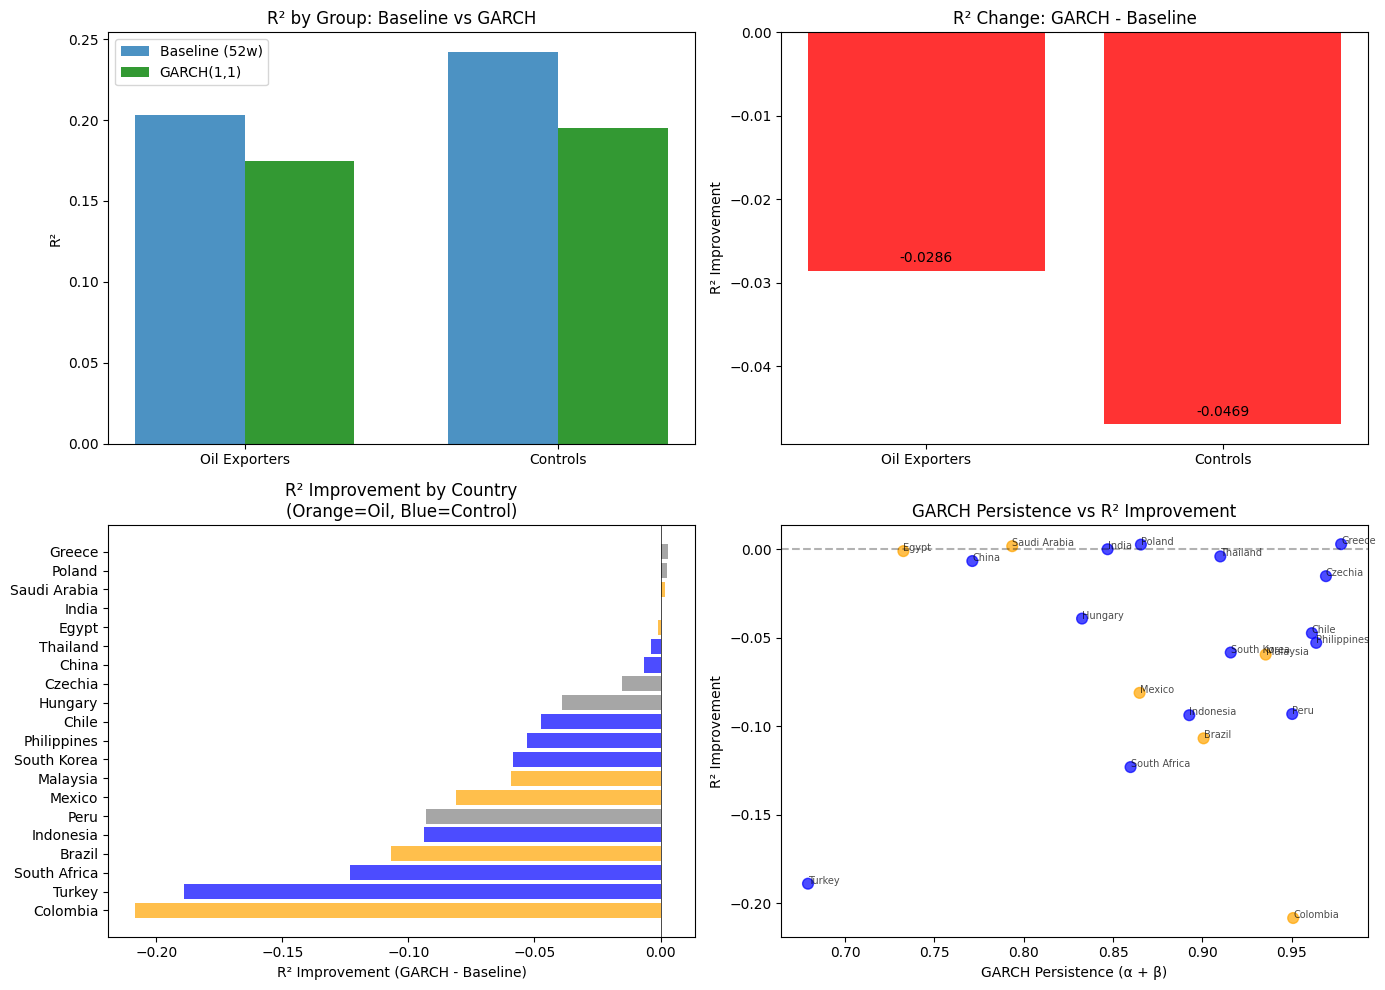

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. R² comparison by group
ax = axes[0, 0]
x = np.arange(len(group_df))
width = 0.35
ax.bar(x - width/2, group_df['r2_baseline'], width, label='Baseline (52w)', alpha=0.8)
ax.bar(x + width/2, group_df['r2_garch'], width, label='GARCH(1,1)', alpha=0.8, color='green')
ax.set_xticks(x)
ax.set_xticklabels(group_df['group'])
ax.set_ylabel('R²')
ax.set_title('R² by Group: Baseline vs GARCH')
ax.legend()

# 2. R² improvement by group
ax = axes[0, 1]
colors = ['green' if x > 0 else 'red' for x in group_df['r2_improvement']]
bars = ax.bar(group_df['group'], group_df['r2_improvement'], color=colors, alpha=0.8)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_ylabel('R² Improvement')
ax.set_title('R² Change: GARCH - Baseline')
for bar, val in zip(bars, group_df['r2_improvement']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:+.4f}', ha='center')

# 3. R² improvement by country
ax = axes[1, 0]
country_df_sorted = country_df.sort_values('r2_improvement', ascending=True)
colors = ['orange' if g == 'oil_exporter' else ('blue' if g == 'control' else 'gray') 
          for g in country_df_sorted['group']]
ax.barh(country_df_sorted['country'], country_df_sorted['r2_improvement'], color=colors, alpha=0.7)
ax.axvline(0, color='k', linestyle='-', linewidth=0.5)
ax.set_xlabel('R² Improvement (GARCH - Baseline)')
ax.set_title('R² Improvement by Country\n(Orange=Oil, Blue=Control)')

# 4. Scatter: GARCH params vs R² improvement
ax = axes[1, 1]
merged = country_df.merge(garch_df[['country', 'alpha', 'beta', 'persistence']], on='country')
colors = ['orange' if g == 'oil_exporter' else 'blue' for g in merged['group']]
ax.scatter(merged['persistence'], merged['r2_improvement'], c=colors, alpha=0.7, s=60)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('GARCH Persistence (α + β)')
ax.set_ylabel('R² Improvement')
ax.set_title('GARCH Persistence vs R² Improvement')

# Add country labels
for _, row in merged.iterrows():
    ax.annotate(row['country'], (row['persistence'], row['r2_improvement']), 
                fontsize=7, alpha=0.7)

plt.tight_layout()
plt.show()

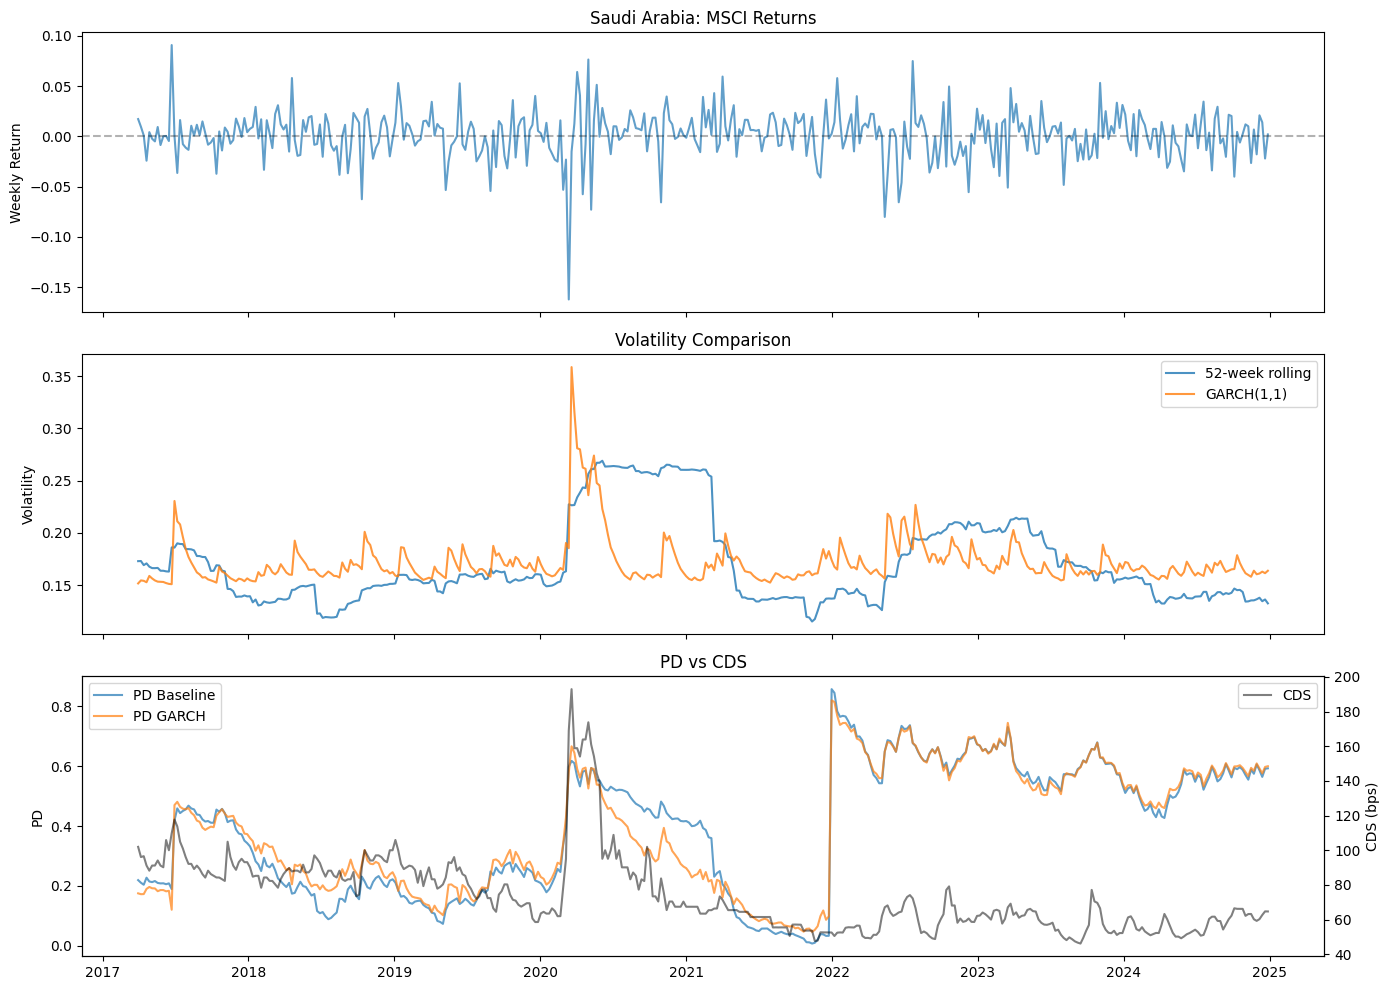

In [40]:
# Time series: PD comparison during crisis
sample_country = 'Saudi Arabia'
sample = panel[panel['country'] == sample_country].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Returns
ax = axes[0]
ax.plot(sample['date'], sample['msci_ret_weekly'], alpha=0.7)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_ylabel('Weekly Return')
ax.set_title(f'{sample_country}: MSCI Returns')

# Volatility
ax = axes[1]
ax.plot(sample['date'], sample['msci_vol_52w'], label='52-week rolling', alpha=0.8)
ax.plot(sample['date'], sample['sigma_garch'], label='GARCH(1,1)', alpha=0.8)
ax.set_ylabel('Volatility')
ax.set_title('Volatility Comparison')
ax.legend()

# PD and CDS
ax = axes[2]
ax2 = ax.twinx()
ax.plot(sample['date'], sample['pd_baseline'], label='PD Baseline', alpha=0.7)
ax.plot(sample['date'], sample['pd_garch'], label='PD GARCH', alpha=0.7)
ax2.plot(sample['date'], sample['cds_spread'], label='CDS', color='black', alpha=0.5)
ax.set_ylabel('PD')
ax2.set_ylabel('CDS (bps)')
ax.set_title('PD vs CDS')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## 10. Summary

In [ ]:
print("\n" + "="*70)
print("MODEL 2: GARCH(1,1) VOLATILITY — SUMMARY")
print("="*70)

print("\n1. GARCH PARAMETERS")
print(f"   Mean α (shock reaction): {garch_df['alpha'].mean():.3f}")
print(f"   Mean β (persistence):    {garch_df['beta'].mean():.3f}")
print(f"   Mean α+β:                {garch_df['persistence'].mean():.3f}")

print("\n2. FULL SAMPLE COMPARISON")
print(f"   Baseline R²: {m1.rsquared:.4f}")
print(f"   GARCH R²:    {m2.rsquared:.4f}")
print(f"   Improvement: {m2.rsquared - m1.rsquared:+.4f} ({(m2.rsquared/m1.rsquared-1)*100:+.1f}%)")

print("\n3. BY GROUP")
for _, row in group_df.iterrows():
    print(f"   {row['group']:<15}: Baseline R²={row['r2_baseline']:.4f}, "
          f"GARCH R²={row['r2_garch']:.4f}, Δ={row['r2_improvement']:+.4f}")

print("\n4. DIFF-IN-DIFF")
print(f"   Oil improvement - Control improvement = {oil_imp - ctrl_imp:+.4f}")

print("\n5. INTERPRETATION")
if m2.rsquared > m1.rsquared:
    print("   → GARCH improves over baseline")
    print("   → Time-varying vol better captures credit risk dynamics")
else:
    print("   → Baseline performs as well or better")
    print("   → Smoothed vol sufficient for weekly CDS tracking")

---
## 11. Save Results

In [ ]:
# Save GARCH parameters
garch_df.to_csv('data/processed/model2_garch_params.csv', index=False)

# Save group and country results
group_df.to_csv('data/processed/model2_group_results.csv', index=False)
country_df.to_csv('data/processed/model2_country_results.csv', index=False)

# Key metrics
metrics = {
    'model': 'GARCH(1,1)',
    'beta_full': m2.params['d_pd_garch'],
    't_stat_full': m2.tvalues['d_pd_garch'],
    'r2_full': m2.rsquared,
    'r2_baseline_full': m1.rsquared,
    'r2_improvement': m2.rsquared - m1.rsquared,
    'r2_oil': group_df[group_df['group']=='Oil Exporters']['r2_garch'].values[0],
    'r2_control': group_df[group_df['group']=='Controls']['r2_garch'].values[0],
    'diff_in_diff': oil_imp - ctrl_imp
}
pd.DataFrame([metrics]).to_csv('data/processed/model2_metrics.csv', index=False)

print("Saved:")
print("  - model2_garch_params.csv")
print("  - model2_group_results.csv")
print("  - model2_country_results.csv")
print("  - model2_metrics.csv")